# Question 1

In [2]:
import numpy as np
from scipy.integrate import odeint, solve_ivp, quad
import matplotlib.pyplot as plt

In [3]:
def g(t,r):
    return np.exp(-r*t)

In [4]:
def f(r,p,T1,R0):
    return (R0/p)*quad(g,T1,p+T1,args=(r))[0]-1

In [5]:
def bisect(f,a,b,p,T1,R0,tol):
    while np.abs(b-a)>tol:
        m = f(a,p,T1,R0)
        n = f(b,p,T1,R0)
        c = (a+b)/2
        q = f(c,p,T1,R0)
        if q<0:
            b=c
        else:
            a=c
    return c

In [6]:
def doublingTime(r):
    return (1/r)*np.log(2)

In [7]:
a=0
b=3
p=2
T1=1/7
R0=2.4
tol = 10**(-5)
r = bisect(f,a,b,p,T1,R0,tol)
print(r)

0.8749637603759766


In [8]:
Td=doublingTime(r)
print(Td)

0.7922010167165052


# Question 2

In [9]:
a=0
b=3
p=4
T1=1
R0=1.1
tol = 10**(-5)
r = bisect(f,a,b,p,T1,R0,tol)
print(r)

0.03199195861816406


In [10]:
Td = doublingTime(r)
print(Td)

21.666293984463877


# Question 3

In [46]:
def SEIR(t,X0,betaprime,sigma,gamma,N):
    S,E,I,R = X0
    
    Sdot = -(betaprime/N)*S*I
    Edot = (betaprime/N)*S*I-sigma*E
    Idot = sigma*E-gamma*I
    Rdot = gamma*I
    return [Sdot,Edot,Idot,Rdot]

In [47]:
T = 100
delta_t = 10**(-3)
N = 25000
tspan = (0,T)
betaprime = 1.2
gamma = 1/2
sigma= 7
X0 = [N,1,0,0]


In [48]:
soln = solve_ivp(SEIR,tspan,X0,args=(betaprime,sigma,gamma,N),rtol = 1, atol = 1,max_step=delta_t)

In [49]:
time = soln.t
soln = soln.y.T


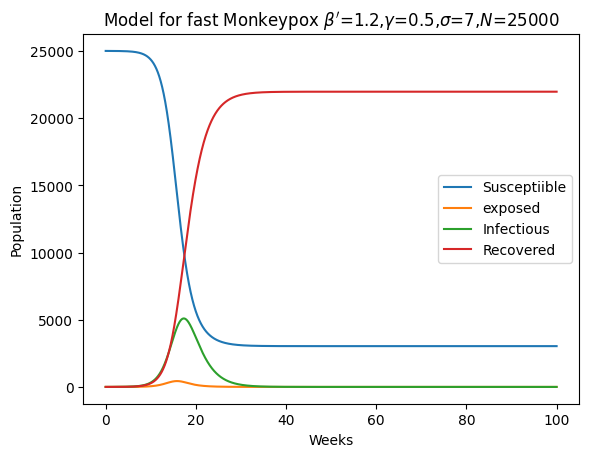

In [50]:
ax=plt.axes()
ax.plot(time,soln[:,0],label = 'Susceptiible')
ax.plot(time,soln[:,1],label = 'exposed')
ax.plot(time,soln[:,2],label = 'Infectious')
ax.plot(time,soln[:,3],label = 'Recovered')
ax.set_title(r"Model for fast Monkeypox $\beta'$=1.2,$\gamma$=0.5,$\sigma$=7,$N$=25000")
ax.set_xlabel('Weeks')
ax.set_ylabel('Population')
ax.legend()

In [114]:
I = soln[:,2]
I.argmax()/1000

17.319

In [131]:
I[17319]

5095.325851684891

In [135]:
(17000+np.where(I[17000:]<1)[0][0])/1000

44.706

In [116]:
S = soln[:,0]
S[-1]/N

0.121387734848417

In [100]:
T = 1000
delta_t = 10**(-3)
N = 25000
tspan = (0,T)
betaprime2 = 0.275
gamma2 = 1/4
sigma2 = 1
X0 = [N,1,0,0]


In [101]:
soln2 = solve_ivp(SEIR,tspan,X0,args=(betaprime2,sigma2,gamma2,N),rtol = 1, atol = 1,max_step=delta_t)

In [102]:
soln_slow = soln2.y.T
time2 = soln2.t

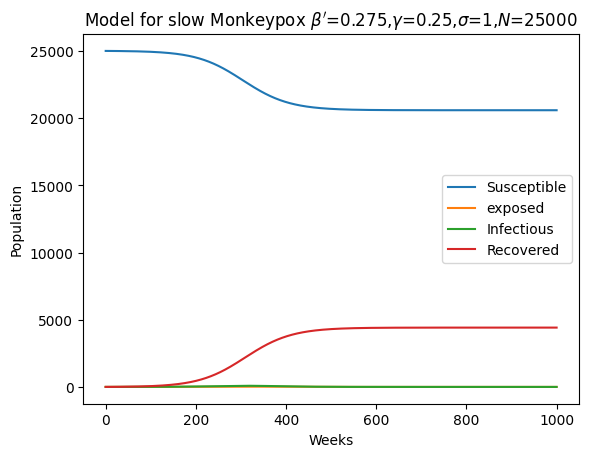

In [103]:
ax=plt.axes()
ax.plot(time2,soln_slow[:,0],label = 'Susceptible')
ax.plot(time2,soln_slow[:,1],label = 'exposed')
ax.plot(time2,soln_slow[:,2],label = 'Infectious')
ax.plot(time2,soln_slow[:,3],label = 'Recovered')
ax.set_title(r"Model for slow Monkeypox $\beta'$=0.275,$\gamma$=0.25,$\sigma$=1,$N$=25000")
ax.set_xlabel('Weeks')
ax.set_ylabel('Population')
ax.legend()

In [138]:
S2 = soln_slow[:,0]
S2[-1]/N

0.8234804320432707

In [112]:
I2 = soln_slow[:,2]
I2.argmax()/1000

309.05

In [136]:
max(I2)

86.06424469389835

In [137]:
(17000+np.where(I2[17000:]<1)[0][0])/1000

612.912

In [151]:
np.where(I2>8)[0][0]/1000

120.201

# Estimate Doubling TIme

In [155]:
a = [max(I2)/2**k for k in range(7)]

In [165]:
b = [np.where(I2>m)[0][0] for m in a[1:]]

In [172]:
c = np.mean([np.abs(b[k]-b[k-1]) for k in range(1,6)])/1000

In [173]:
c

38.2104

In [174]:
b

[219044, 174860, 136071, 99306, 63437, 27992]

In [175]:
a

[86.06424469389835,
 43.03212234694917,
 21.516061173474586,
 10.758030586737293,
 5.379015293368647,
 2.6895076466843233,
 1.3447538233421616]